<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m2_survey_data.csv"

df = pd.read_csv(file_path)

df.head()

,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,WelcomeChange,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase
0,4,I am a developer by profession,No,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,22.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy
1,9,I am a developer by profession,Yes,Once a month or more often,The quality of OSS and closed source software ...,Employed full-time,New Zealand,No,Some college/university study without earning ...,"Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,NaN,23.0,Man,No,Bisexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
2,13,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Somewhat more welcome now than last year,Tech articles written by other developers;Cour...,28.0,Man,No,Straight / Heterosexual,White or of European descent,Yes,Appropriate in length,Easy
3,16,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,United Kingdom,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",NaN,...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,26.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
4,17,I am a developer by profession,Yes,Less than once a month but more than once per ...,The quality of OSS and closed source software ...,Employed full-time,Australia,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,29.0,Man,No,Straight / Heterosexual,Hispanic or Latino/Latina;Multiracial,No,Appropriate in length,Easy


### Task 1: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



In [5]:
df_lang = pd.DataFrame({
    'Age': df['Age'],
    'LanguageWorkedWith': df['LanguageWorkedWith']
})

df_lang = df_lang.dropna()
df_lang = df_lang.drop_duplicates()
df_lang.head()

,Age,LanguageWorkedWith
0,22.0,C;C++;C#;Python;SQL
1,23.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...
2,28.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
3,26.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;T...
4,29.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;Type...


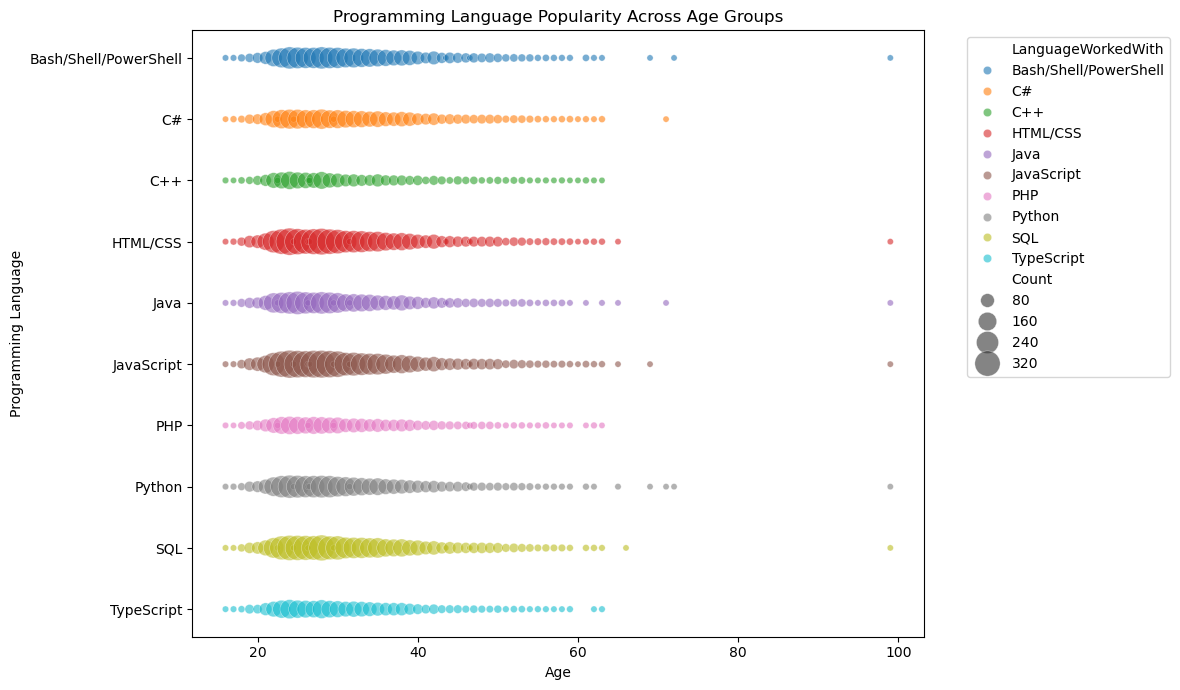

In [7]:
# Split multiple languages into rows
df_lang['LanguageWorkedWith'] = df_lang['LanguageWorkedWith'].str.split(';')
df_lang = df_lang.explode('LanguageWorkedWith')

# Group by Age and Language and count frequency
df_grouped = df_lang.groupby(['Age', 'LanguageWorkedWith']).size().reset_index(name='Count')

# Optional: filter top languages to avoid clutter
top_languages = df_grouped.groupby('LanguageWorkedWith')['Count'].sum().nlargest(10).index
df_grouped = df_grouped[df_grouped['LanguageWorkedWith'].isin(top_languages)]

# Plot
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df_grouped,
    x='Age',
    y='LanguageWorkedWith',
    size='Count',
    hue='LanguageWorkedWith',
    sizes=(20, 400),
    alpha=0.6,
    legend='brief'
)

plt.title('Programming Language Popularity Across Age Groups')
plt.xlabel('Age')
plt.ylabel('Programming Language')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


In [11]:
df_db = pd.DataFrame({
    'Age': df['Age'],
    'DatabaseDesireNextYear': df['DatabaseDesireNextYear'],
    'JobSat': df['JobSat']
})

df_db = df_db.dropna()
df_db = df_db.drop_duplicates()
df_db.head()

,Age,DatabaseDesireNextYear,JobSat
0,22.0,MySQL;SQLite,Slightly satisfied
1,23.0,PostgreSQL;Redis;SQLite,Slightly satisfied
2,28.0,Firebase;MySQL;Redis,Very satisfied
3,26.0,Elasticsearch;MongoDB;Microsoft SQL Server;SQLite,Slightly satisfied
4,29.0,Elasticsearch;Firebase;MongoDB;PostgreSQL,Neither satisfied nor dissatisfied


In [12]:
# Split multiple databases into rows
df_db['DatabaseDesireNextYear'] = df_db['DatabaseDesireNextYear'].str.split(';')
df_db = df_db.explode('DatabaseDesireNextYear')

# Group and count
df_grouped = df_db.groupby(['JobSat', 'DatabaseDesireNextYear']).size().reset_index(name='Count')

# Optional: keep only top databases for clarity
top_dbs = df_grouped.groupby('DatabaseDesireNextYear')['Count'].sum().nlargest(10).index
df_grouped = df_grouped[df_grouped['DatabaseDesireNextYear'].isin(top_dbs)]

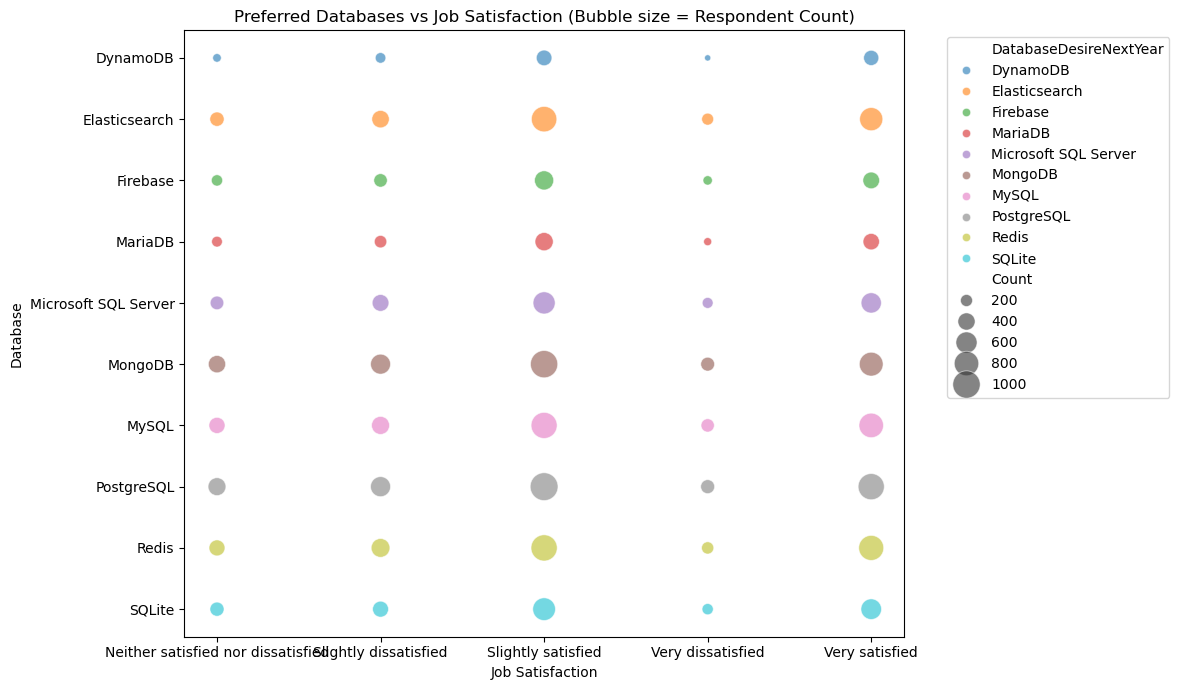

In [13]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df_grouped,
    x='JobSat',
    y='DatabaseDesireNextYear',
    size='Count',
    hue='DatabaseDesireNextYear',
    sizes=(20, 400),
    alpha=0.6
)

plt.xticks()
plt.title('Preferred Databases vs Job Satisfaction (Bubble size = Respondent Count)')
plt.xlabel('Job Satisfaction')
plt.ylabel('Database')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between platforms used (`PlatformWorkedWith`) and age groups.

- Use bubble size to represent the frequency of platform usage.


In [20]:
df_collab =  pd.DataFrame({
    'PlatformWorkedWith': df['PlatformWorkedWith'],
    'Age': df['Age']
})

df_collab = df_collab.dropna()
df_collab = df_collab.drop_duplicates()
df_collab.head()

,PlatformWorkedWith,Age
0,Linux;Windows,22.0
1,AWS;Docker;Heroku;Linux;MacOS;Slack,23.0
2,Android;AWS;Docker;IBM Cloud or Watson;iOS;Lin...,28.0
4,Arduino;Docker;Heroku;Raspberry Pi;WordPress,29.0
5,Android;AWS;Microsoft Azure,31.0


In [21]:
df_plot = df_collab.copy()

In [22]:
# Split tools into multiple rows
df_plot['PlatformWorkedWith'] = df_plot['PlatformWorkedWith'].str.split(';')
df_plot = df_plot.explode('PlatformWorkedWith')

# Create age groups (bins)
df_plot['AgeGroup'] = pd.cut(
    df_plot['Age'],
    bins=[15, 25, 35, 45, 55, 65, 100],
    labels=['15-25', '25-35', '35-45', '45-55', '55-65', '65+']
)

C:\Users\marko\AppData\Local\Temp\ipykernel_16608\553308242.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df_plot.groupby(['AgeGroup', 'PlatformWorkedWith']).size().reset_index(name='Count')


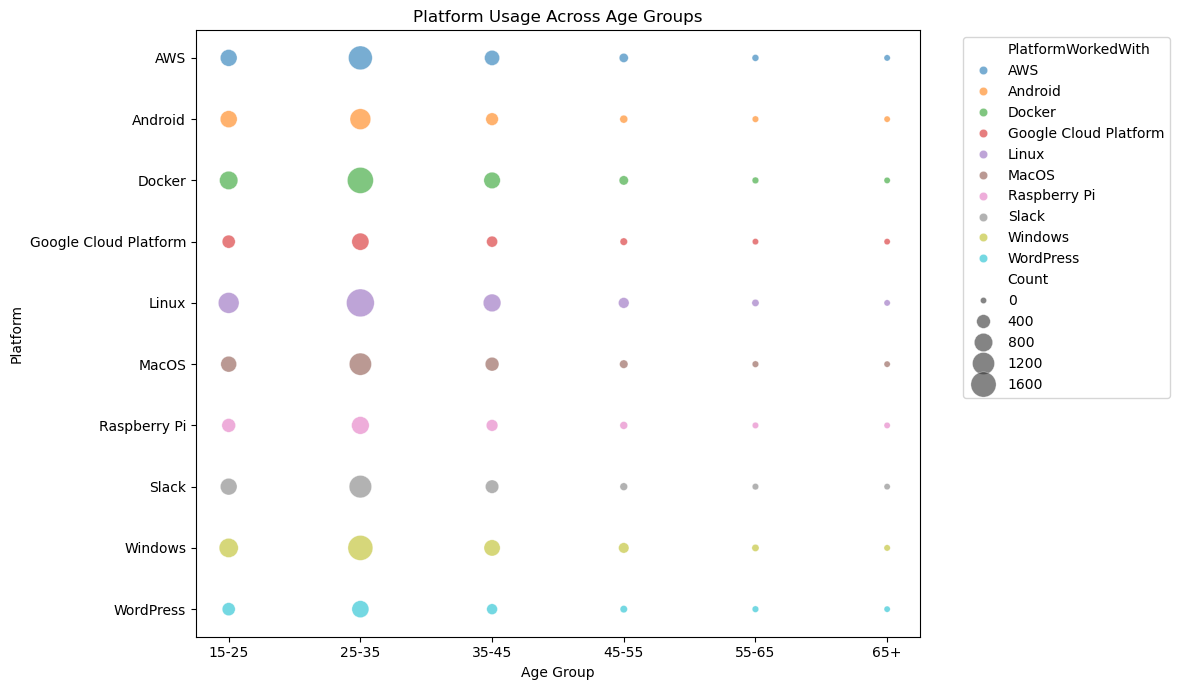

In [23]:
# Group and count frequency
df_grouped = df_plot.groupby(['AgeGroup', 'PlatformWorkedWith']).size().reset_index(name='Count')

# Optional: keep top tools to reduce clutter
top_tools = df_grouped.groupby('PlatformWorkedWith')['Count'].sum().nlargest(10).index
df_grouped = df_grouped[df_grouped['PlatformWorkedWith'].isin(top_tools)]

# Plot
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df_grouped,
    x='AgeGroup',
    y='PlatformWorkedWith',
    size='Count',
    hue='PlatformWorkedWith',
    sizes=(20, 400),
    alpha=0.6
)

plt.title('Platform Usage Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Platform')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
